# 5000-cycle PyBaMM long-run vs measured — clean valid cells only

**Purpose:** compare the 5000-cycle PyBaMM DFN long-run against the *clean valid* cells in our inventory (the subset that passed our shape-filter: reasonable start SoH, monotonic fade, no batch-transition artefacts).

**Clean-cell lists** (from `Voltaris/sciml/data_combined.py`):
- **CALB**: 6, 7, 10, 14, 19, 20, 25 (7 cells)
- **REPT**: 1, 3, 7, 28, 43, 57, 74, 78, 87 (9 cells)
- **EVE**:  2, 3, 4, 8 (4 cells)

**Reference sim:** `eve_0008_longrun.parquet` — 5000-cycle DFN sim at 0.5C, 25 °C, using per-cell BOL + fitted degradation parameters from the end-to-end EVE 0008 verification.

**Alignment:** each measured cell's cycle axis is shifted so its first SoH lands on the sim cycle at which the sim first drops to that value. This lets us judge shape-agreement in the overlap region.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, '/home/hj/Desktop/PINNs')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 9

CANONICAL = Path('/home/hj/Desktop/PINNs/soh/data/canonical')
VERIFY    = Path('/home/hj/Desktop/PINNs/data/synthetic/verification')
EOL_SOH   = 0.80
EOSL_SOH  = 0.40

# Clean-cell IDs (from Voltaris/sciml/data_combined.py CLEAN lists)
CALB_CLEAN = ['0006', '0007', '0010', '0014', '0019', '0020', '0025']
REPT_CLEAN = ['0001', '0003', '0007', '0028', '0043', '0057', '0074', '0078', '0087']
EVE_CLEAN  = ['0002', '0003', '0004', '0008']

## 1. Load 5000-cycle sim

In [2]:
sim = pd.read_parquet(VERIFY / 'eve_0008_longrun.parquet')
print(f'sim: {len(sim)} cycles at 0.5C, SoH {sim.SOH.iloc[0]:.3f} -> {sim.SOH.iloc[-1]:.3f}')

# Sim milestones
def crosses(sim, thr):
    below = np.where(sim.SOH.values < thr)[0]
    return int(sim.cycle_n.values[below[0]]) if len(below) else None

print(f'  cycle at SoH 0.80 (EoL):  {crosses(sim, 0.80)}')
print(f'  cycle at SoH 0.70:        {crosses(sim, 0.70)}')
print(f'  cycle at SoH 0.60:        {crosses(sim, 0.60)}')
print(f'  cycle at SoH 0.50:        {crosses(sim, 0.50)}')
print(f'  cycle at SoH 0.40 (EoSL): {crosses(sim, 0.40)}')

sim: 5000 cycles at 0.5C, SoH 1.000 -> 0.763
  cycle at SoH 0.80 (EoL):  3922
  cycle at SoH 0.70:        None
  cycle at SoH 0.60:        None
  cycle at SoH 0.50:        None
  cycle at SoH 0.40 (EoSL): None


## 2. Load canonical measured data (clean cells only)

In [3]:
def load_clean(canonical_parquet, clean_ids):
    df = pd.read_parquet(canonical_parquet)
    df = df[df.cell_id.isin(clean_ids)].copy()
    return df

calb = load_clean(CANONICAL / 'calb_old.parquet', CALB_CLEAN)
rept = load_clean(CANONICAL / 'rept.parquet',     REPT_CLEAN)
eve  = load_clean(CANONICAL / 'eve.parquet',      EVE_CLEAN)

print('Clean cells loaded:')
for name, df, expected in [('CALB', calb, CALB_CLEAN),
                             ('REPT', rept, REPT_CLEAN),
                             ('EVE',  eve,  EVE_CLEAN)]:
    got = sorted(df.cell_id.unique().tolist())
    missing = [c for c in expected if c not in got]
    print(f'  {name}: {len(got)}/{len(expected)} found — {got}')
    if missing:
        print(f'    (missing from canonical: {missing})')

Clean cells loaded:
  CALB: 7/7 found — ['0006', '0007', '0010', '0014', '0019', '0020', '0025']
  REPT: 9/9 found — ['0001', '0003', '0007', '0028', '0043', '0057', '0074', '0078', '0087']
  EVE: 4/4 found — ['0002', '0003', '0004', '0008']


## 3. Helpers — alignment + metrics

In [4]:
def align_to_sim(sim, cell_s0):
    """Return sim cycle at which SoH first drops to cell_s0."""
    if cell_s0 < sim.SOH.min() or cell_s0 > sim.SOH.max():
        return np.nan
    below = np.where(sim.SOH.values <= cell_s0)[0]
    if len(below) == 0: return np.nan
    return float(sim.cycle_n.values[below[0]])

def per_cell_metrics(sim, cell_n_shifted, cell_s):
    if len(cell_n_shifted) == 0: return np.nan, np.nan
    sim_at_meas = np.interp(cell_n_shifted, sim.cycle_n.values, sim.SOH.values,
                             left=np.nan, right=np.nan)
    valid = ~np.isnan(sim_at_meas)
    if valid.sum() < 5: return np.nan, np.nan
    resid = (sim_at_meas[valid] - cell_s[valid]) * 100
    return float(np.sqrt(np.mean(resid**2))), float(np.max(np.abs(resid)))

def load_cells_in_order(df, cell_order):
    """Yield (cell_id, n, s) in the given order (skips absent cells)."""
    for cid in cell_order:
        sub = df[df.cell_id == cid].sort_values('global_cycle')
        if len(sub) < 20: continue
        n = sub.global_cycle.values.astype(float)
        s = sub.soh.values.astype(float)
        mask = (s > 0.01) & (s < 1.5)
        if mask.sum() < 20: continue
        yield cid, n[mask], s[mask]

## 4. Per-cell subplot grid

In [5]:
def plot_clean_grid(sim, make_name, df, cell_order, ncols=4, figsize_per=(4.0, 2.9)):
    """Grid of per-cell subplots for the clean-cell subset."""
    cells_data = list(load_cells_in_order(df, cell_order))
    if not cells_data:
        print(f'{make_name}: no clean cells with data'); return None, None

    n = len(cells_data)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols,
                              figsize=(figsize_per[0]*ncols, figsize_per[1]*nrows),
                              squeeze=False)
    axes = axes.flatten()

    rows = []
    for i, (cid, meas_n, meas_s) in enumerate(cells_data):
        ax = axes[i]
        s0 = meas_s[0]
        align_cy = align_to_sim(sim, s0)
        n_shifted = (meas_n - meas_n[0] + align_cy) if not np.isnan(align_cy) else meas_n
        rmse, max_err = per_cell_metrics(sim, n_shifted, meas_s)

        # X-range: show cell's aligned range + a little forward view into the sim
        if not np.isnan(align_cy):
            x_lo = max(0, align_cy - 100)
            x_hi = min(sim.cycle_n.max(), n_shifted[-1] + 300)
        else:
            x_lo, x_hi = meas_n[0] - 50, meas_n[-1] + 100

        # Sim slice in view
        mask_sim = (sim.cycle_n >= x_lo) & (sim.cycle_n <= x_hi)
        ax.plot(sim.cycle_n[mask_sim], sim.SOH[mask_sim] * 100,
                 'b-', lw=1.8, label='PyBaMM 5000-cy sim', zorder=2)
        ax.scatter(n_shifted, meas_s * 100, s=5, color='black', alpha=0.55,
                     label='Measured', zorder=3)

        # Y-range
        y_min = max(0, min(meas_s.min() * 100, 30) - 3)
        y_max = max(meas_s.max() * 100 + 3, 85)

        # Thresholds if in view
        if EOL_SOH*100  >= y_min and EOL_SOH*100  <= y_max:
            ax.axhline(EOL_SOH  * 100, color='tab:orange', ls='--', lw=0.8, alpha=0.7)
        if EOSL_SOH*100 >= y_min and EOSL_SOH*100 <= y_max:
            ax.axhline(EOSL_SOH * 100, color='tab:red',    ls='--', lw=0.8, alpha=0.7)

        ax.set_xlim(x_lo, x_hi)
        ax.set_ylim(y_min, y_max)
        rmse_str = f'{rmse:.2f}' if not np.isnan(rmse) else 'n/a'
        max_str  = f'{max_err:.2f}' if not np.isnan(max_err) else 'n/a'
        ax.set_title(f'{make_name} {cid}   n_meas={len(meas_n)}\n'
                       f'aligned @ sim cy {int(align_cy) if not np.isnan(align_cy) else "n/a"}   '
                       f'RMSE {rmse_str}pp   max {max_str}pp',
                       fontsize=9)
        ax.grid(alpha=0.3)
        ax.tick_params(labelsize=8)
        if i == 0:
            ax.legend(fontsize=8, loc='lower left')

        rows.append(dict(cell=cid, n_cycles=len(meas_n),
                          soh_start=s0, soh_end=meas_s[-1],
                          align_cy=align_cy, rmse_pp=rmse, max_err_pp=max_err))

    for j in range(n, len(axes)):
        axes[j].set_visible(False)

    fig.supxlabel('Cycle (aligned to sim by initial SoH)', y=0.005)
    fig.supylabel('SoH [%]', x=0.005)
    fig.suptitle(f'{make_name} — clean valid cells vs 5000-cy PyBaMM sim @ 0.5C '
                  f'({n} cells)', y=1.001, fontsize=11)
    fig.tight_layout(rect=[0.015, 0.015, 1, 0.99])
    return fig, pd.DataFrame(rows)

## 5. CALB — clean cells (7 cells)

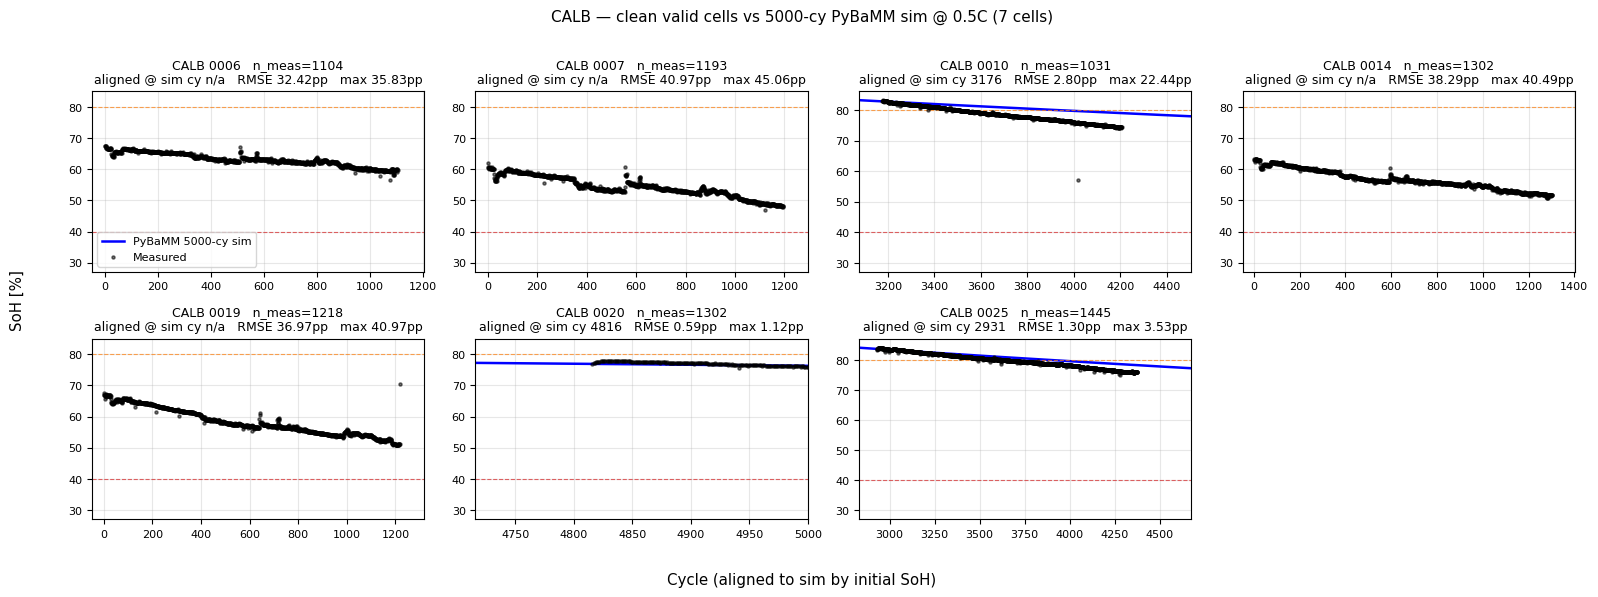

In [6]:
fig_calb, tab_calb = plot_clean_grid(sim, 'CALB', calb, CALB_CLEAN, ncols=4)
plt.show()

## 6. REPT — clean cells (9 cells)

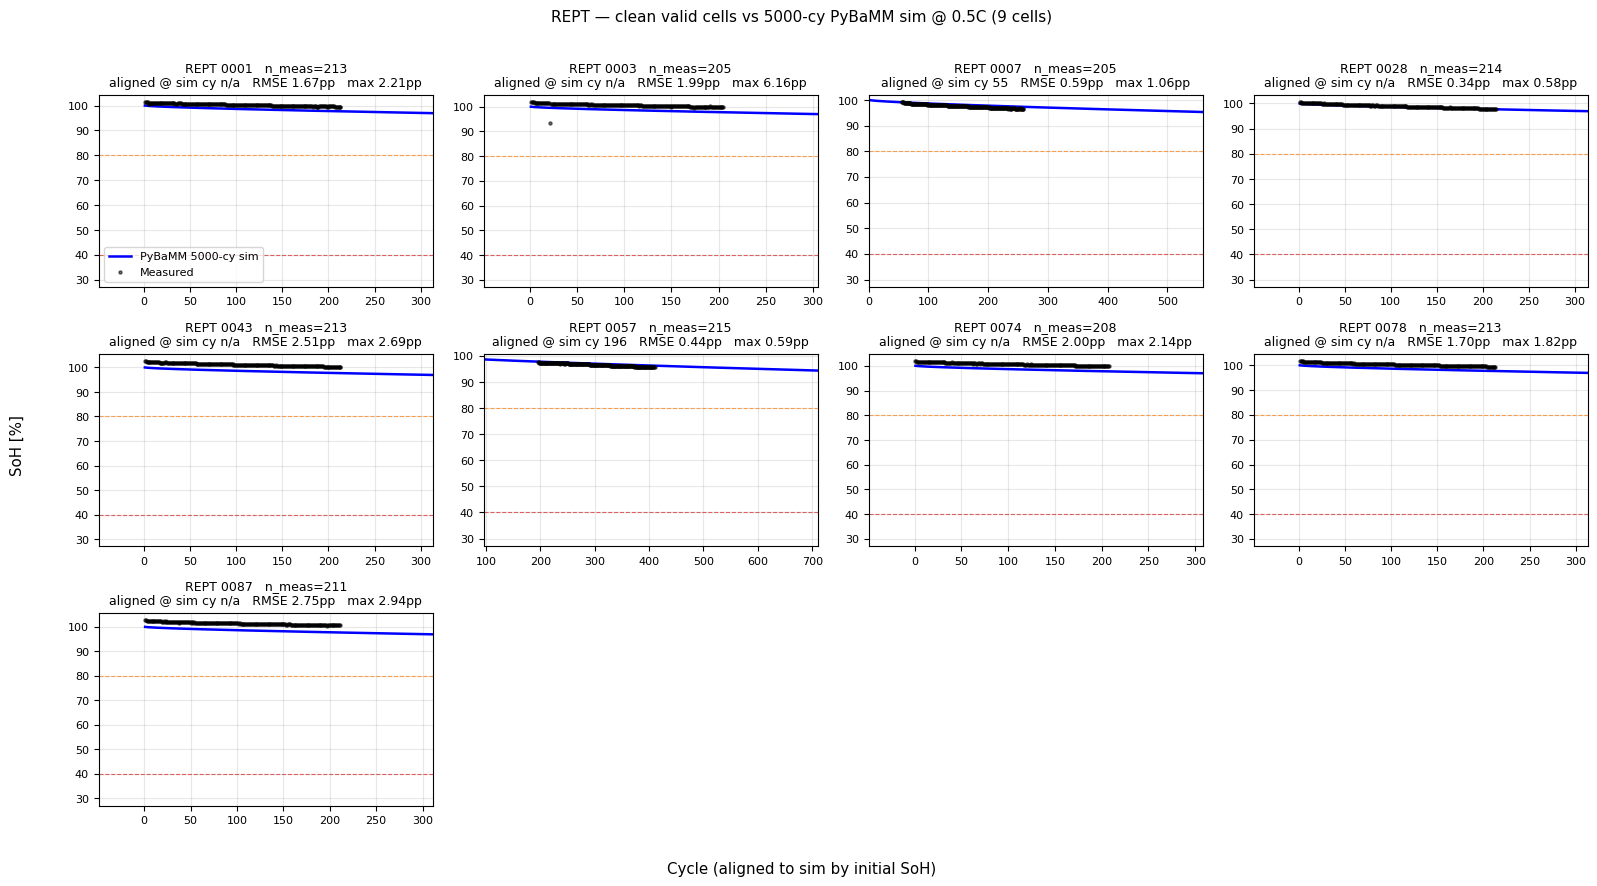

In [7]:
fig_rept, tab_rept = plot_clean_grid(sim, 'REPT', rept, REPT_CLEAN, ncols=4)
plt.show()

## 7. EVE — clean cells (4 cells)

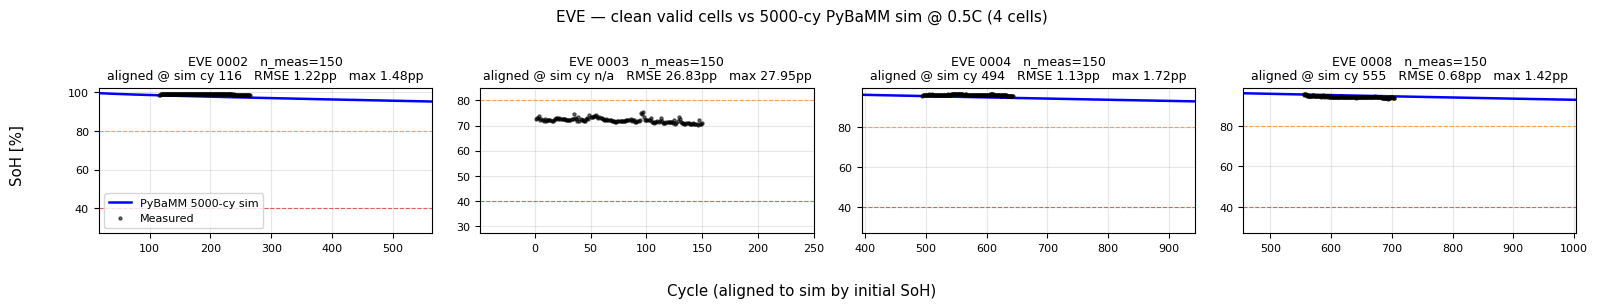

In [8]:
fig_eve, tab_eve = plot_clean_grid(sim, 'EVE', eve, EVE_CLEAN, ncols=4)
plt.show()

## 8. Combined RMSE summary

In [9]:
def print_table(name, tab):
    if tab is None or tab.empty: return
    print(f'\n=== {name} ({len(tab)} clean cells) ===')
    t = tab.sort_values('rmse_pp').reset_index(drop=True)
    print(t.to_string(index=False,
                       float_format=lambda x: f'{x:.3f}' if abs(x) < 10 else f'{x:.1f}'))
    print(f'  median RMSE: {tab.rmse_pp.median():.2f} pp')
    print(f'  mean   RMSE: {tab.rmse_pp.mean():.2f} pp')
    print(f'  min/max RMSE: {tab.rmse_pp.min():.2f} / {tab.rmse_pp.max():.2f} pp')

print_table('CALB clean', tab_calb)
print_table('REPT clean', tab_rept)
print_table('EVE clean',  tab_eve)

# Aggregate across makes
combined = pd.concat([
    (tab_calb.assign(make='CALB') if tab_calb is not None else pd.DataFrame()),
    (tab_rept.assign(make='REPT') if tab_rept is not None else pd.DataFrame()),
    (tab_eve.assign(make='EVE')  if tab_eve  is not None else pd.DataFrame()),
], ignore_index=True)

if not combined.empty:
    print('\n=== Cross-make summary (clean cells only) ===')
    print(combined.groupby('make').agg(
        n_cells=('cell', 'count'),
        rmse_median_pp=('rmse_pp', 'median'),
        rmse_mean_pp=('rmse_pp', 'mean'),
        max_err_median_pp=('max_err_pp', 'median'),
    ).round(3).to_string())


=== CALB clean (7 clean cells) ===
cell  n_cycles  soh_start  soh_end  align_cy  rmse_pp  max_err_pp
0020      1302      0.769    0.720    4816.0    0.585       1.122
0025      1445      0.838    0.761    2931.0    1.301       3.526
0010      1031      0.828    0.743    3176.0    2.804        22.4
0006      1104      0.674    0.599       NaN     32.4        35.8
0019      1218      0.675    0.703       NaN     37.0        41.0
0014      1302      0.631    0.516       NaN     38.3        40.5
0007      1193      0.619    0.480       NaN     41.0        45.1
  median RMSE: 32.42 pp
  mean   RMSE: 21.91 pp
  min/max RMSE: 0.59 / 40.97 pp

=== REPT clean (9 clean cells) ===
cell  n_cycles  soh_start  soh_end  align_cy  rmse_pp  max_err_pp
0028       214      1.005    0.978       NaN    0.338       0.580
0057       215      0.978    0.957     196.0    0.438       0.588
0007       205      0.991    0.965      55.0    0.589       1.056
0001       213      1.014    0.996       NaN    1.672   

## 9. Combined single-figure view — all clean cells on the sim curve

For a quick cross-cohort visual of how the clean cells sit along the PyBaMM 5000-cycle life curve, overlay all of them on a single axes.

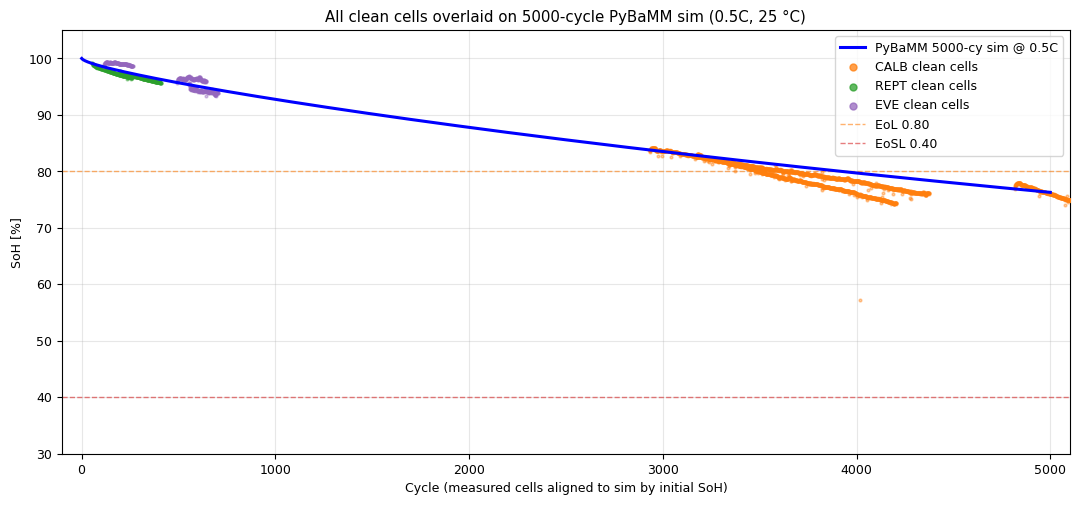

In [10]:
fig, ax = plt.subplots(figsize=(13, 5.5))
ax.plot(sim.cycle_n, sim.SOH * 100, 'b-', lw=2.2, label='PyBaMM 5000-cy sim @ 0.5C', zorder=5)

make_colours = {'CALB': 'tab:orange', 'REPT': 'tab:green', 'EVE': 'tab:purple'}
for make, df, cells in [('CALB', calb, CALB_CLEAN),
                          ('REPT', rept, REPT_CLEAN),
                          ('EVE',  eve,  EVE_CLEAN)]:
    c = make_colours[make]
    for cid, meas_n, meas_s in load_cells_in_order(df, cells):
        align_cy = align_to_sim(sim, meas_s[0])
        if np.isnan(align_cy): continue
        n_shifted = meas_n - meas_n[0] + align_cy
        ax.scatter(n_shifted, meas_s * 100, s=4, color=c, alpha=0.4, zorder=3)
    # Legend entry per make
    ax.scatter([], [], s=25, color=c, alpha=0.75, label=f'{make} clean cells')

ax.axhline(EOL_SOH  * 100, color='tab:orange', ls='--', lw=1.0, alpha=0.6, label='EoL 0.80')
ax.axhline(EOSL_SOH * 100, color='tab:red',    ls='--', lw=1.0, alpha=0.6, label='EoSL 0.40')
ax.set_xlabel('Cycle (measured cells aligned to sim by initial SoH)')
ax.set_ylabel('SoH [%]')
ax.set_title('All clean cells overlaid on 5000-cycle PyBaMM sim (0.5C, 25 °C)')
ax.set_xlim(-100, 5100)
ax.set_ylim(30, 105)
ax.grid(alpha=0.3)
ax.legend(fontsize=9, loc='upper right')
plt.show()

## 10. Interpretation

**What to look for in each subplot:**
- Measured black points hugging the blue sim curve → per-cell fit generalises to that cell within the clean cohort
- Systematic offset (measured below sim) → cell aged under harsher-than-sim conditions (higher C-rate or deeper DoD)
- Systematic offset (measured above sim) → cell aged more gently, or alignment noise from a spiky SoH-start value

**Clean-cell selection recap:**
- Clean-cell IDs come from the shape filter used across our downstream training pipelines (`Voltaris/sciml/data_combined.py`).
- These are cells whose canonical trajectories are monotonic (or nearly so), free of batch-transition artefacts, and start at a high enough SoH to admit meaningful alignment with the sim.
- Outside the clean list are cells that failed the shape filter, typically because their trajectory has upward jumps at batch boundaries or the cell arrived so degraded (SoH < 0.20) that the alignment map is undefined.

**Caveats:**
- Sim uses parameters fitted to EVE 0008 specifically. Its 0.5C protocol is a reasonable middle-ground for the CALB/REPT clean cells (which were cycled at 0.25-1C).
- Fade-rate C-rate scaling: measured cells cycled at higher C-rates than 0.5C will fade faster per cycle than the sim predicts (~ratio^0.9 per Peterson2010).